# Project 04 - Computer Vision: CNNs & Transfer Learning

We'll build the *intuition* of computer vision here with small, runnable demos and real diagrams
(convolution, feature maps, augmentation), then give you the **production PyTorch code** to
fine-tune a pretrained model on a GPU. The heavy training is meant to run on a **Kaggle GPU**
(Settings -> Accelerator -> GPU); the concept cells below run anywhere.

**What you'll learn**
- How a computer "sees" an image (just a grid of numbers).
- What a **convolution** does, and what a **feature map** is (you'll SEE it).
- **Transfer learning**: standing on a model pretrained on millions of images.
- **Data augmentation**: making more training data for free.

## The scenario
A farm wants an app: snap a photo of a leaf, and the app says which **disease** it has. You have
only a few thousand labelled leaf photos - far too few to train a vision model from zero. The
trick the whole industry uses is **transfer learning**: take a model already trained on millions
of general images and gently adapt it to leaves. This notebook builds that intuition.

## Foundations (plain English)
- **An image is numbers.** A grayscale image is a grid of pixel brightnesses (0=black, 1=white);
  a colour image has 3 such grids (Red, Green, Blue).
- **Convolution** slides a tiny grid of weights (a **filter/kernel**) across the image, computing
  a weighted sum at each spot. Different filters detect different things (vertical edges,
  horizontal edges, blur). The output is a **feature map**.
- **CNN (Convolutional Neural Network)** stacks many learned filters; early layers find edges,
  later layers find shapes and objects. The network *learns* the filters during training.
- **Transfer learning** reuses a pretrained CNN's learned filters and only retrains the final
  classifier ("head") for your classes - so a few thousand images is enough.
- **Augmentation** = randomly flipping/rotating/cropping training images to teach the model that
  a leaf is still a leaf when shifted or mirrored.

### Cell 1 - imports and a synthetic image
We make a simple 40x40 grayscale picture (a filled square + a diagonal line) so we can clearly
see what convolution filters do.

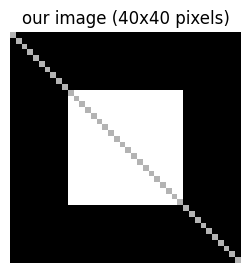

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

img = np.zeros((40, 40))
img[10:30, 10:30] = 1.0          # a bright filled square (has vertical + horizontal edges)
np.fill_diagonal(img, 0.7)       # a diagonal line
plt.figure(figsize=(3,3)); plt.imshow(img, cmap="gray"); plt.title("our image (40x40 pixels)")
plt.axis("off"); plt.show()

### Cell 2 - what a convolution is (in ~6 lines)
`conv2d` slides a 3x3 `kernel` over the image and, at each position, multiplies the patch by the
kernel and sums it. That single operation is the heart of every CNN.

In [2]:
def conv2d(image, kernel):
    kh, kw = kernel.shape
    out = np.zeros((image.shape[0]-kh+1, image.shape[1]-kw+1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(image[i:i+kh, j:j+kw] * kernel)   # patch . kernel
    return out
print("conv2d ready")

conv2d ready


### Cell 3 - diagram: feature maps from different filters
Three classic filters: a **vertical-edge** detector, a **horizontal-edge** detector, and a
**blur**. See how each lights up different parts of the image - that's feature extraction. A CNN
*learns* thousands of such filters automatically.

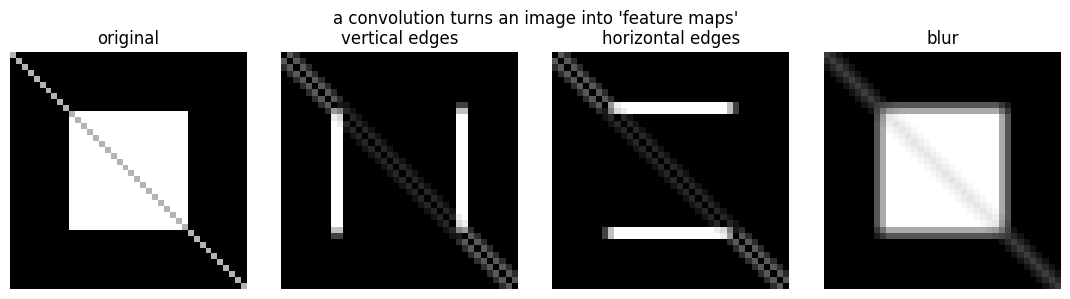

In [3]:
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])     # responds to vertical edges
sobel_y = sobel_x.T                                   # responds to horizontal edges
blur    = np.ones((3,3))/9.0                           # smooths

maps = {"original": img, "vertical edges": np.abs(conv2d(img, sobel_x)),
        "horizontal edges": np.abs(conv2d(img, sobel_y)), "blur": conv2d(img, blur)}
fig, ax = plt.subplots(1, 4, figsize=(11, 3))
for a,(name,m) in zip(ax, maps.items()):
    a.imshow(m, cmap="gray"); a.set_title(name); a.axis("off")
plt.suptitle("a convolution turns an image into 'feature maps'"); plt.tight_layout(); plt.show()

### Cell 4 - diagram: data augmentation (free extra training data)
We make several altered copies of the image - flips, a rotation, added noise, a crop. The label
("square") doesn't change, so the model learns to be robust to these variations.

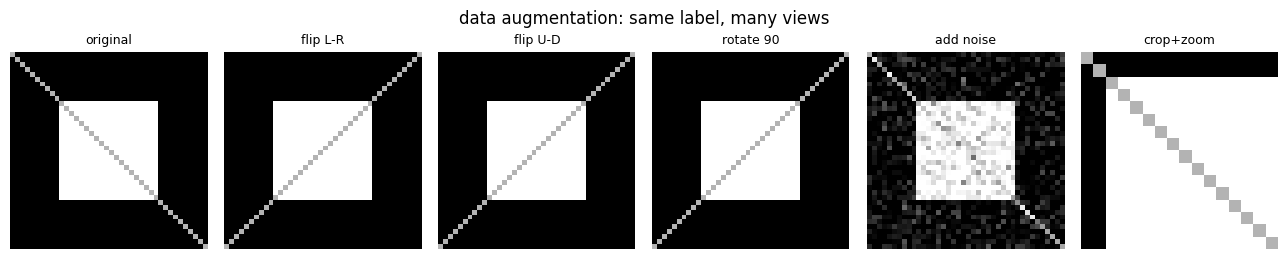

In [4]:
aug = {
    "original": img,
    "flip L-R": np.fliplr(img),
    "flip U-D": np.flipud(img),
    "rotate 90": np.rot90(img),
    "add noise": np.clip(img + np.random.default_rng(0).normal(0,0.15,img.shape), 0, 1),
    "crop+zoom": np.kron(img[8:24, 8:24], np.ones((2,2))),   # crop the centre and upscale
}
fig, ax = plt.subplots(1, 6, figsize=(13, 2.6))
for a,(name,m) in zip(ax, aug.items()):
    a.imshow(m, cmap="gray"); a.set_title(name, fontsize=9); a.axis("off")
plt.suptitle("data augmentation: same label, many views"); plt.tight_layout(); plt.show()

### Cell 5 - diagram: how transfer learning is wired
We draw the idea: keep the pretrained backbone's learned layers (frozen, in blue) and replace
only the final **head** (trained, in teal) for your own classes.

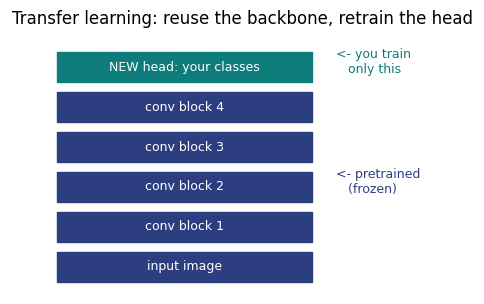

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.4)); ax.axis("off")
layers = ["input image","conv block 1","conv block 2","conv block 3","conv block 4"]
for i, name in enumerate(layers):
    ax.add_patch(plt.Rectangle((0.1, 0.05+i*0.16), 0.55, 0.12, color="#2d3e80"))
    ax.text(0.375, 0.11+i*0.16, name, color="white", ha="center", va="center", fontsize=9)
ax.text(0.7, 0.45, "<- pretrained\n   (frozen)", color="#2d3e80", fontsize=9, va="center")
ax.add_patch(plt.Rectangle((0.1, 0.05+5*0.16), 0.55, 0.12, color="#0e7c7b"))
ax.text(0.375, 0.11+5*0.16, "NEW head: your classes", color="white", ha="center", va="center", fontsize=9)
ax.text(0.7, 0.93, "<- you train\n   only this", color="#0e7c7b", fontsize=9, va="center")
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.set_title("Transfer learning: reuse the backbone, retrain the head"); plt.show()

## The real thing - run this on a Kaggle GPU
Everything above built intuition on a toy image with NumPy. Here is the **production code** to
fine-tune a real pretrained model on your own images. Create a Kaggle Notebook, set
**Accelerator = GPU**, attach an image dataset, and paste this in. It uses `timm` (a library of
pretrained vision models) and does the standard **two-stage** fine-tune.

```python
# pip install timm torch torchvision  (already available on Kaggle GPU)
import timm, torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1) data + augmentation (the train transform randomly flips/crops; val does not)
train_tf = transforms.Compose([transforms.RandomResizedCrop(224),
                               transforms.RandomHorizontalFlip(),
                               transforms.ToTensor()])
val_tf   = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                               transforms.ToTensor()])
train_ds = datasets.ImageFolder("/kaggle/input/your-data/train", train_tf)
val_ds   = datasets.ImageFolder("/kaggle/input/your-data/val",   val_tf)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=32)

# 2) a pretrained backbone with a fresh head sized to YOUR number of classes
device = "cuda"
model = timm.create_model("resnet50", pretrained=True, num_classes=len(train_ds.classes)).to(device)

# 3) STAGE 1 - freeze the backbone, train only the head (fast, stable)
for p in model.parameters(): p.requires_grad = False
for p in model.get_classifier().parameters(): p.requires_grad = True
opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

def run_epoch(dl, train):
    model.train() if train else model.eval()
    correct = total = 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        if train: opt.zero_grad()
        out = model(x); loss = loss_fn(out, y)
        if train: loss.backward(); opt.step()
        correct += (out.argmax(1) == y).sum().item(); total += len(y)
    return correct/total

for epoch in range(3):
    run_epoch(train_dl, True)
    print("stage1 val acc:", run_epoch(val_dl, False))

# 4) STAGE 2 - unfreeze everything and fine-tune gently (small learning rate)
for p in model.parameters(): p.requires_grad = True
opt = torch.optim.Adam(model.parameters(), lr=1e-5)
for epoch in range(3):
    run_epoch(train_dl, True)
    print("stage2 val acc:", run_epoch(val_dl, False))

torch.save(model.state_dict(), "model.pt")
```

**Then deploy a live demo** (a Gradio app -> Hugging Face Space):
```python
import gradio as gr
def predict(image):
    # preprocess -> model(image) -> return {class_name: probability}
    ...
gr.Interface(predict, gr.Image(type="pil"), gr.Label(num_top_classes=3)).launch()
```
Track loss/accuracy with Weights & Biases, push the model to the Hugging Face Hub, and put the
Space link on a resume - a live demo is the most convincing artifact you can show.

## What just happened (recap)
- An image is just numbers; a **convolution** slides a filter to make **feature maps** (you saw
  edges and blur appear).
- **Augmentation** multiplies your data for free by making label-preserving variations.
- A **CNN** learns thousands of filters; **transfer learning** reuses a pretrained one and only
  retrains the head, so a few thousand images suffice.
- The Kaggle-GPU code does the standard **two-stage** fine-tune and a Gradio demo.

## Extensions
- **Change the filter:** design your own 3x3 kernel in Cell 3 - what does it detect?
- **Few images:** with only 500 photos, transfer learning + augmentation is the move (training
  from scratch would overfit badly).
- **CNN vs ViT:** swap `resnet50` for a Vision Transformer (`vit_base_patch16_224`) and compare.
- **Project goal:** fine-tune on a real Kaggle image dataset, hit a target accuracy, and ship a
  Hugging Face Space.

## Mini-glossary
**pixel** a brightness number - **convolution** sliding-filter operation - **kernel/filter** the
small weight grid - **feature map** a convolution's output - **CNN** stacked learned filters -
**transfer learning** reuse a pretrained backbone, retrain the head - **augmentation**
label-preserving image transforms - **backbone/head** the reusable body vs the task-specific top.